In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Chargement ---
df = pd.read_csv("winequality-red.csv", sep=";")
print(f"Dimensions initiales : {df.shape}")

# --- 1. Valeurs manquantes ---
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print("→ Aucune valeur manquante ✅")

# --- 2. Doublons ---
nb_doublons = df.duplicated().sum()
print(f"\n=== Doublons : {nb_doublons} lignes ===")
df = df.drop_duplicates()
print(f"Dimensions après suppression : {df.shape}")



Dimensions initiales : (1599, 12)

=== Valeurs manquantes ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
→ Aucune valeur manquante ✅

=== Doublons : 240 lignes ===
Dimensions après suppression : (1359, 12)


In [8]:
# --- 3. Centrage et réduction ---
X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_cr = scaler.fit_transform(X)
X_cr = pd.DataFrame(X_cr, columns=X.columns)

print("\n=== Données centrées-réduites (5 premières lignes) ===")
print(X_cr.head().round(3))
print(f"\nMoyennes (≈ 0) : {X_cr.mean().round(3).values}")
print(f"Écarts-types (≈ 1) : {X_cr.std().round(3).values}")



=== Données centrées-réduites (5 premières lignes) ===
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0         -0.524             0.932       -1.393          -0.461     -0.246   
1         -0.294             1.916       -1.393           0.057      0.200   
2         -0.294             1.260       -1.189          -0.165      0.079   
3          1.664            -1.364        1.472          -0.461     -0.266   
4         -0.524             0.713       -1.393          -0.535     -0.266   

   free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  \
0               -0.469                -0.384    0.584  1.292     -0.579   
1                0.872                 0.604    0.049 -0.708      0.125   
2               -0.086                 0.215    0.156 -0.321     -0.051   
3                0.106                 0.394    0.691 -0.966     -0.461   
4               -0.277                -0.204    0.584  1.292     -0.579   

   alcohol  
0   -0.954 


=== Répartition des classes (quality_cat) ===
quality_cat
mauvais    640
moyen      535
bon        184
Name: count, dtype: int64


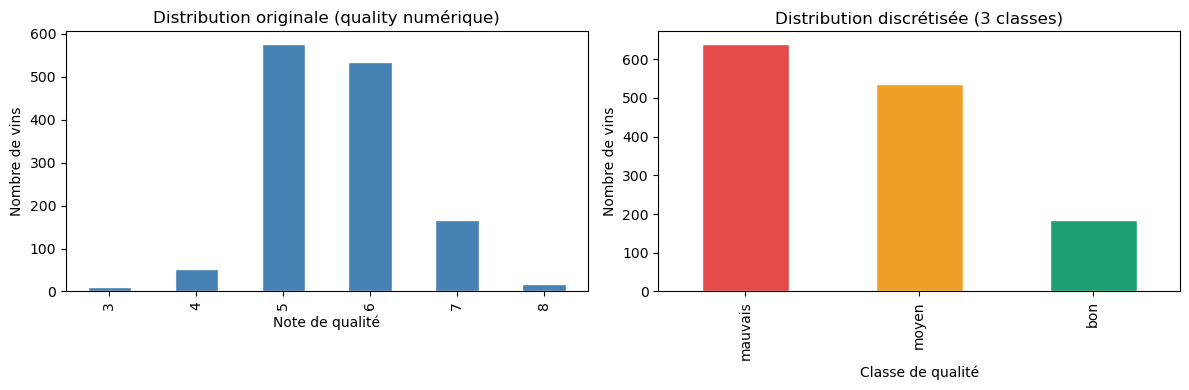

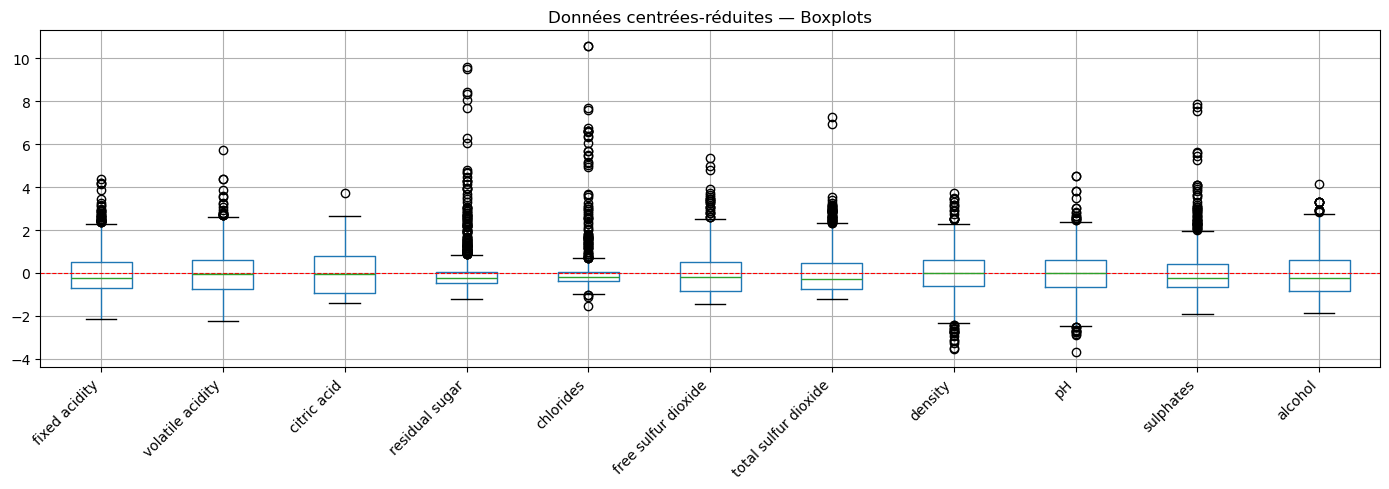

In [9]:
# --- 4. Discrétisation de quality ---
def discretize_quality(q):
    if q <= 5:
        return "mauvais"
    elif q == 6:
        return "moyen"
    else:
        return "bon"

df = df.reset_index(drop=True)
df['quality_cat'] = df['quality'].apply(discretize_quality)
df['quality_bin'] = (df['quality'] >= 7).astype(int)

print("\n=== Répartition des classes (quality_cat) ===")
print(df['quality_cat'].value_counts())

# --- 5. Visualisation de la discrétisation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Distribution originale (quality numérique)")
axes[0].set_xlabel("Note de qualité")
axes[0].set_ylabel("Nombre de vins")

colors_cat = {'mauvais': '#E24B4A', 'moyen': '#EF9F27', 'bon': '#1D9E75'}
df['quality_cat'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=[colors_cat[c] for c in df['quality_cat'].value_counts().index],
    edgecolor='white')
axes[1].set_title("Distribution discrétisée (3 classes)")
axes[1].set_xlabel("Classe de qualité")
axes[1].set_ylabel("Nombre de vins")

plt.tight_layout()
plt.savefig("preparation_distribution.png", dpi=150)
plt.show()

# --- 6. Boxplots des données centrées-réduites ---
plt.figure(figsize=(14, 5))
X_cr.boxplot()
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.title("Données centrées-réduites — Boxplots")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("preparation_boxplots_cr.png", dpi=150)
plt.show()

# --- 7. Sauvegarde ---
X_cr.to_csv("X_cr.csv", index=False)
df.to_csv("df_prepared.csv", index=False)
